# 이미지 연산 (Image Operation)

- 이미지는 배열(array)로 표현되기에, 여러가지 연산 가능


In [15]:
import os
import numpy as np
import cv2
import matplotlib.pyplot as plt

from PIL import Image
import requests
from io import BytesIO

base_path = r"/Users/leo/LeoData/MyCode/KoreaITAcademy/LangChain/dataset/ComputerVision/01"

def cv2_imshow(image):
    cv2.imshow('image', image)
    cv2.waitKey(0)
    cv2.destroyAllWindows()
    for _ in range(5):
        cv2.waitKey(1)

def plt_imshow(image, axis=True):  # OpenCV 이미지를 matplotlib 으로 출력하기
    img = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    plt.imshow(img)
    plt.axis(axis)
    plt.show()    


(431, 640, 3)


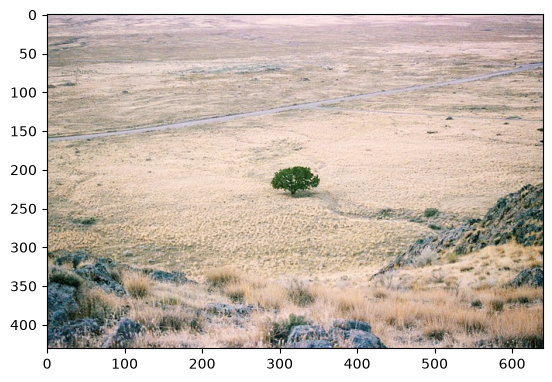

In [16]:
tree = cv2.imread(os.path.join(base_path, 'tree.jpg'))
print(tree.shape)
plt_imshow(tree)

## Pixel Value

In [17]:
temp_px = tree[200, 200]
temp_px  # 특정 pixel값 [B, G, R]

array([189, 207, 230], dtype=uint8)

In [18]:
# 특정 channel값
tree[200, 200, 2]

np.uint8(230)

## 값 변경

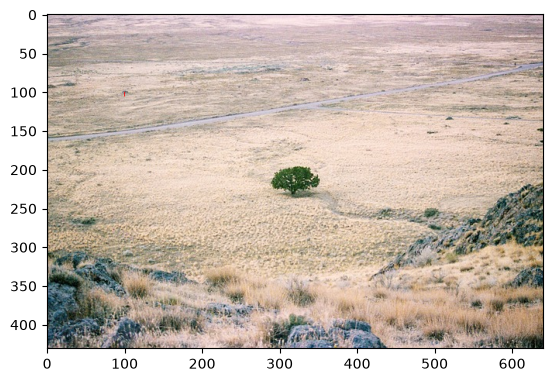

In [19]:
tree[100, 100] = [0, 0, 255]
tree[101, 100] = [0, 0, 255]
tree[102, 100] = [0, 0, 255]
tree[103, 100] = [0, 0, 255]
tree[104, 100] = [0, 0, 255]
tree[105, 100] = [0, 0, 255]

plt_imshow(tree)

## 슬라이싱, 인덱싱

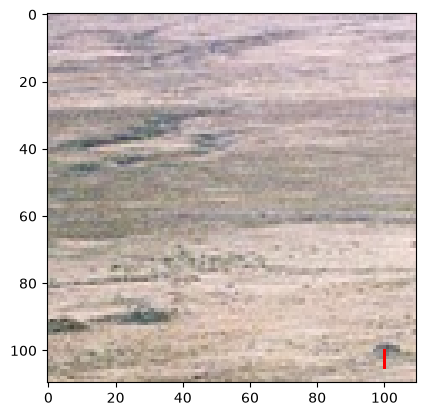

In [20]:
plt_imshow(tree[:110, :110])

In [21]:
a = [10, 20, 30, 40, 50]
a[1:4] = [400, 500, 600]

a

[10, 400, 500, 600, 50]

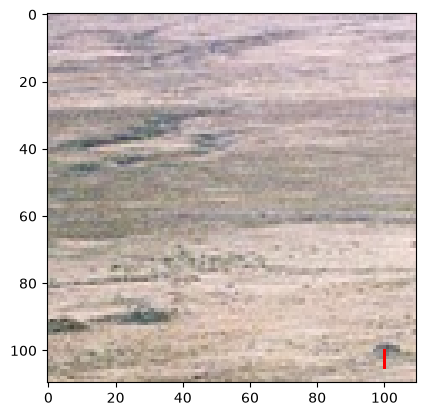

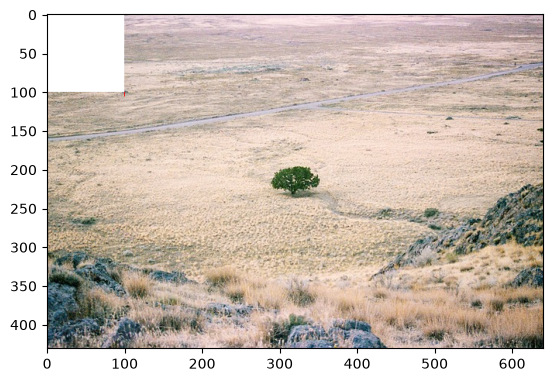

In [22]:
white_box = tree[:110, :110]  # 슬라이싱 결과
plt_imshow(white_box)

white_box = [255, 255, 255]
tree[:100, :100] = white_box  # 슬라이싱 결과에 대입 -> 좌상단(100, 100) 영역을 [255, 255, 255] 값으로 채움

plt_imshow(tree)

## 이미지 ROI

- 이미지 작업시에는 특정 pixel단위 보다는 특정 영역단위로 작업을 하게 되는데 이것을 **ROI** (Region of Interest, Region Of Image)라고 함
  
- ROI 설정은 Numpy의 indexing 을 사용
  
  - 특정 영역을 copy 할 수도 있음


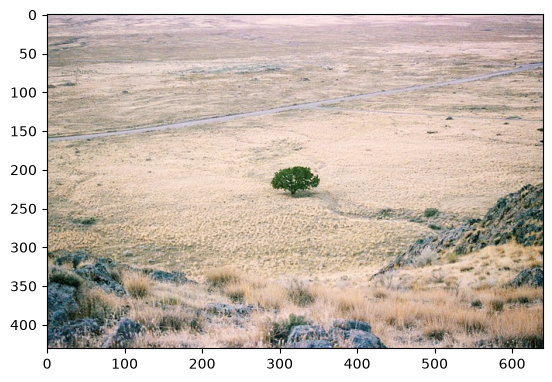

In [23]:
# 원본
tree = cv2.imread(os.path.join(base_path, 'tree.jpg'))
plt_imshow(tree)

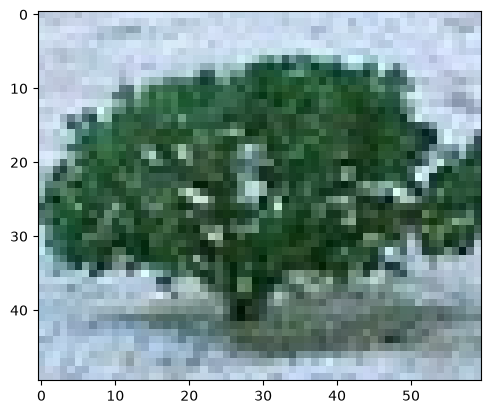

In [26]:
# 위에서 나무만 가져오기
t = tree[190:240, 290:350]
plt.imshow(t)

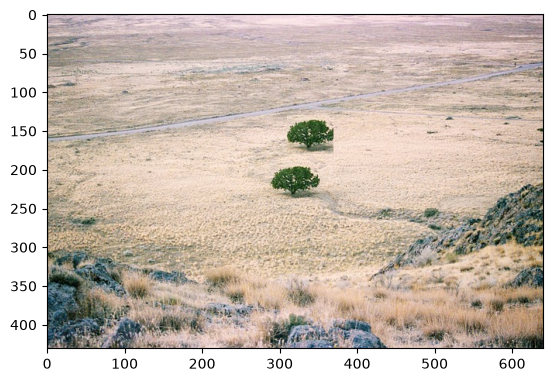

In [27]:
# 위 나무를 원본의 특정 위치에 넣어보기
tree[130:180, 310:370] = t
plt_imshow(tree)

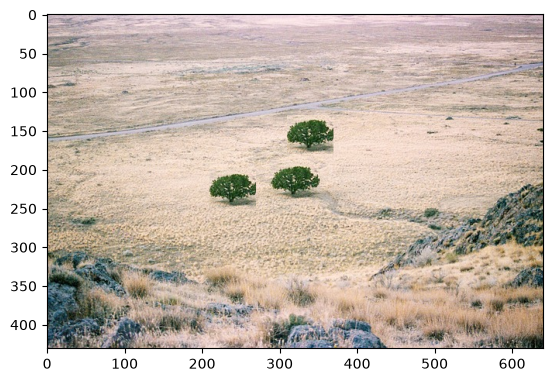

In [28]:
tree[200:250, 210:270] = t
plt_imshow(tree)

## 이미지의 Channels

- B, G, R로 구성된 채널을 분리, 합칠 수 있음

  - `cv2.split()`

  - `cv2.merge()`


In [29]:
tree.shape

(431, 640, 3)

In [38]:
tree[..., 2]  # Red
tree[:, :, 2]

array([[179, 170, 170, ..., 170, 177, 171],
       [161, 178, 188, ..., 190, 179, 179],
       [194, 199, 194, ..., 206, 204, 200],
       ...,
       [ 89, 141, 182, ...,   0,  24,  47],
       [ 98,  95, 122, ...,  10,  37,  27],
       [ 76,  75, 113, ...,  30,  22,  21]], shape=(431, 640), dtype=uint8)

In [39]:
b, g, r = cv2.split(tree)  # 각 channel로 분리 -> tuple[array]

print(b.shape)  # blue channel

(431, 640)


In [41]:
# 3개 channel 합치기
img = cv2.merge((b, g, r))
img.shape

(431, 640, 3)

In [ ]:
# ↑ split()은 내부적으로 메모리 copy가 동작하는 함수이기 때문에 비용이 많이 든다.
# 반면 NumPy의 기본 슬라이싱은 일반적으로 복사 없이 View를 만든다.

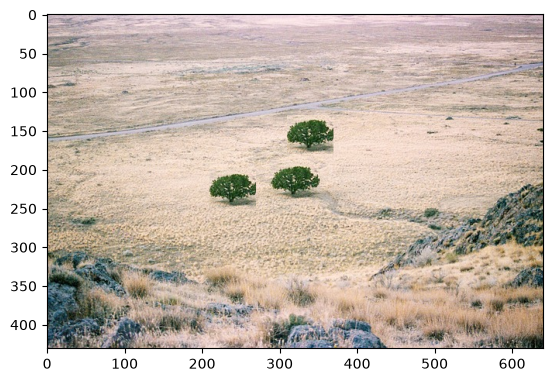

In [42]:
plt_imshow(img)

In [43]:
# Red Channel
img[:, :, 2]  

array([[179, 170, 170, ..., 170, 177, 171],
       [161, 178, 188, ..., 190, 179, 179],
       [194, 199, 194, ..., 206, 204, 200],
       ...,
       [ 89, 141, 182, ...,   0,  24,  47],
       [ 98,  95, 122, ...,  10,  37,  27],
       [ 76,  75, 113, ...,  30,  22,  21]], shape=(431, 640), dtype=uint8)

In [50]:
# Red Channel 값을 0으로 변경
img[:, :, 2] = 0

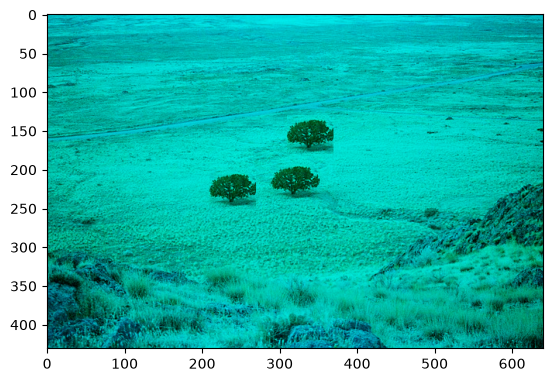

In [51]:
plt_imshow(img)

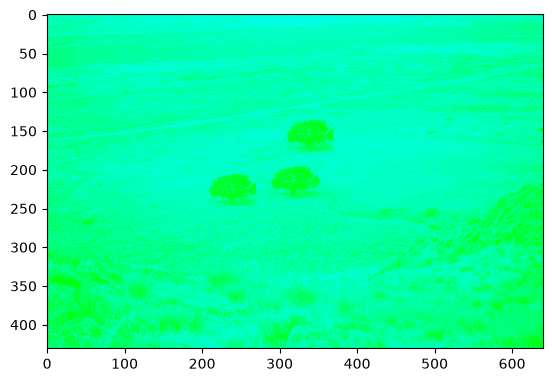

In [55]:
# Green Channel 값을 255으로 변경
img[:, :, 1] = 255
plt_imshow(img)

## 이미지 더하기
- `cv2.add()`

- `cv2.addWeighted()`

- `Numpy` 더하기 연산

- (참고) 
  - `cv2.add()` 는 'Saturation 연산' 을 한다 
    - `Saturation` 연산은 '한계값'을 정하고 그 값을 벗어나는 경우는 모두 특정 값으로 계산하는 방식

    - 이미지에서는 0이하는 모두 0, 255이상은 모두 255로 표현
  
  - `Numpy` : 'modulo 연산'
    - a와 b는 n으로 나눈 나머지 값이 같다라는 의미

    - 이미지에서는 연산의 결과가 256보다 큰 경우는 256으로 나눈 나머지 값으로 결정


In [67]:
# 위 연산방식의 차이점을 알아보자

x = np.uint8([[250]])
y = np.uint8([[10]])

In [68]:
# Numpy의 uint8의 표현 범위는 0~255까지 연산결과가 벗어나면 modulo 연산의 결과가 나옴
x + y

array([[4]], dtype=uint8)

In [69]:
# 반면 
cv2.add(x, y)

array([[255]], dtype=uint8)

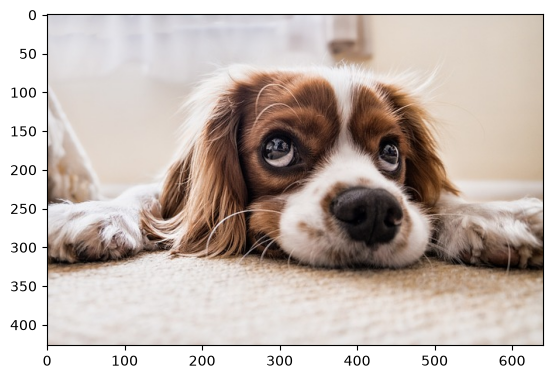

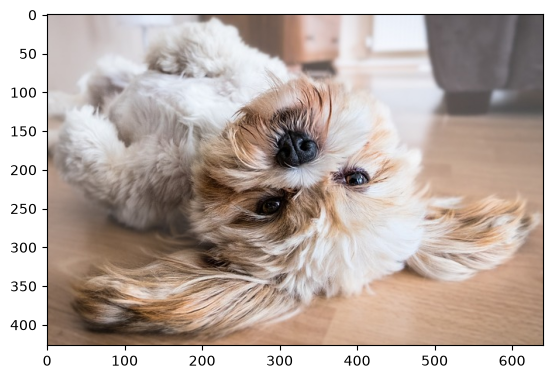

In [70]:
dog1 = cv2.imread(os.path.join(base_path, 'dog1.jpg'), cv2.IMREAD_COLOR)
dog2 = cv2.imread(os.path.join(base_path, 'dog2.jpg'), cv2.IMREAD_COLOR)

plt_imshow(dog1)
plt_imshow(dog2)

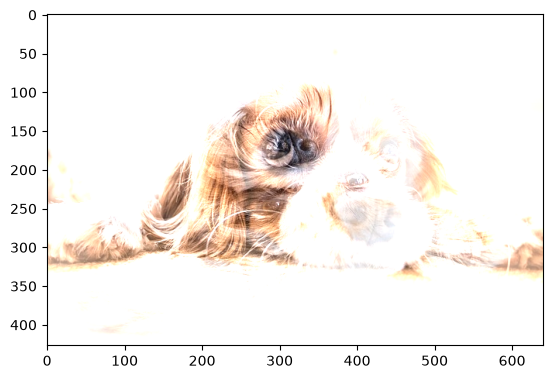

In [71]:
plt_imshow(cv2.add(dog1, dog2))

In [72]:
# 두 이미지가 겹쳐 더해지면서
# saturation연산에 의해 max 한계값(255)에 수렴 

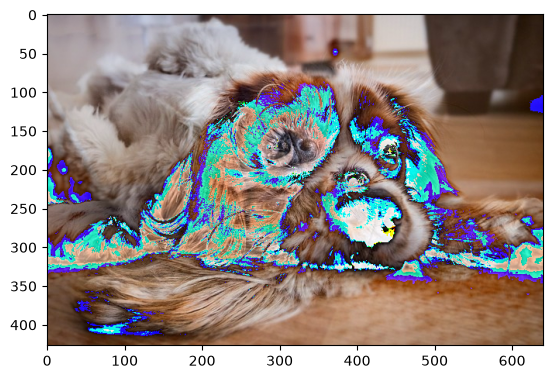

In [73]:
# Numpy 덧셈연산을 하게되면
plt_imshow(dog1 + dog2)

## 비트 연산
- AND, OR, NOT, XOR 연산
  - `bitwise_and` : 둘다 0이 아닌 경우만 값을 통과

  - `bitwise_or` : 둘중 하나가 0이 아니면 값을 통과

  - `bitwise_not` : 해당 값에 대해 부정값을 통과

  - `bitwise_xor` : 두 요소의 논리적 배타값 통과


(5120, 5120, 3)


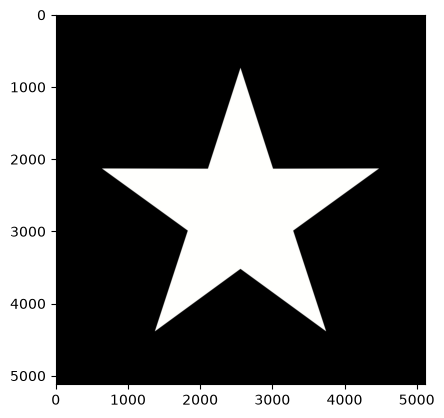

In [74]:
star = cv2.imread(os.path.join(base_path, 'star.jpg'))
print(star.shape)
plt_imshow(star)

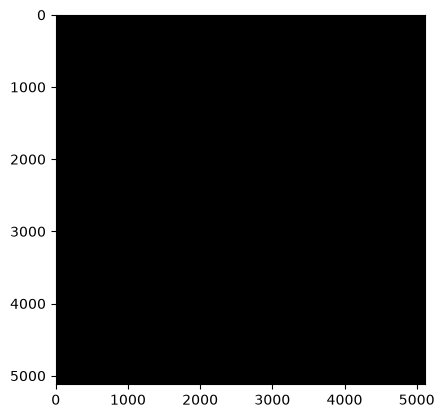

In [77]:
# star와 동일한 크기의 검정색 이미지 준비
black_img = np.zeros(star.shape, np.uint8)
plt_imshow(black_img)

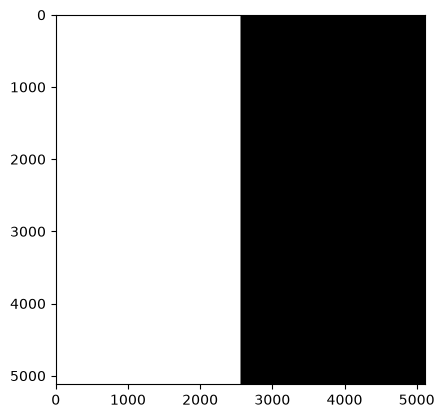

In [78]:
# 위에서 좌측 1/2 만 white 로 만들기
black_img[:, :2560, :] = (255, 255, 255)
plt_imshow(black_img)

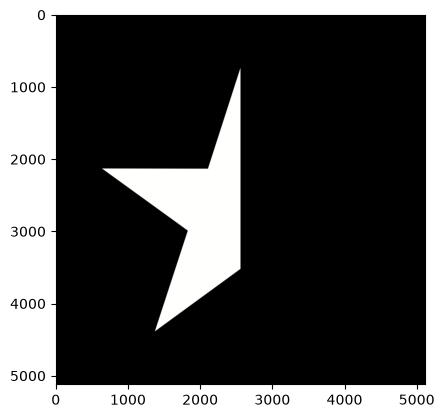

In [79]:
plt_imshow(cv2.bitwise_and(black_img, star))

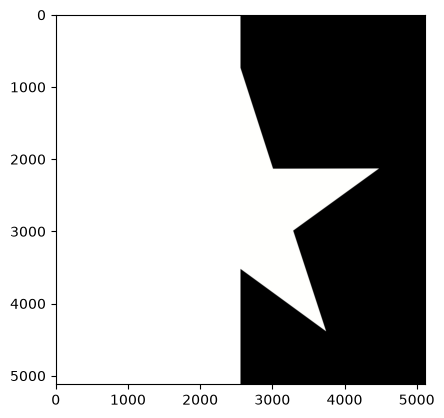

In [80]:
plt_imshow(cv2.bitwise_or(black_img, star))

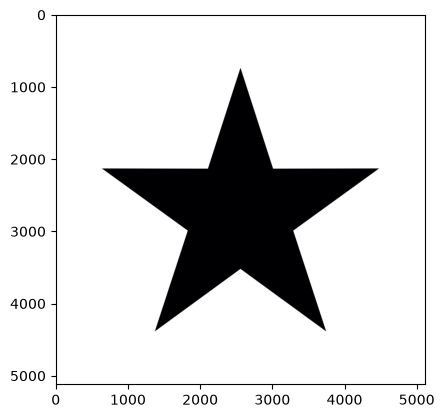

In [81]:
plt_imshow(cv2.bitwise_not(star))

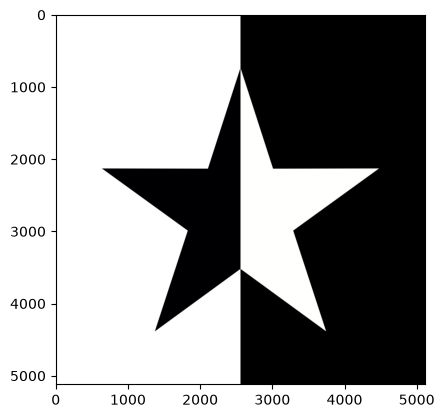

In [82]:
plt_imshow(cv2.bitwise_xor(black_img, star))

### 비트 연산 활용 예시 - lenna 이미지에 OpenCV 로고 넣기


- 이미지 (OpenCV logo)
  - https://img1.daumcdn.net/thumb/R800x0/?scode=mtistory2&fname=https%3A%2F%2Ft1.daumcdn.net%2Fcfile%2Ftistory%2F2361FF4A586B8FFE1A

  <img src="https://img1.daumcdn.net/thumb/R800x0/?scode=mtistory2&fname=https%3A%2F%2Ft1.daumcdn.net%2Fcfile%2Ftistory%2F2361FF4A586B8FFE1A" width="300">


(517, 585, 3)


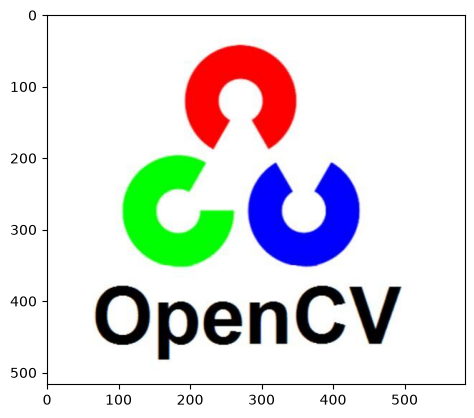

In [86]:
logo = cv2.imread(os.path.join(base_path, 'opencv_logo.jpg'))
print(logo.shape)
plt_imshow(logo)

(512, 512, 3)


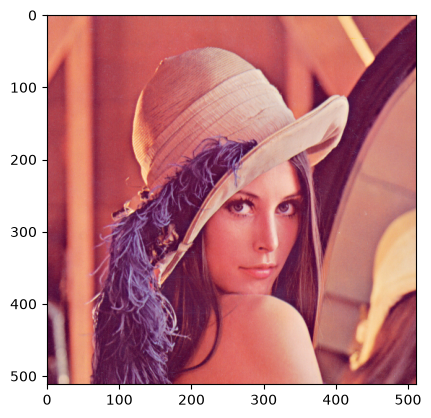

In [85]:
lenna = cv2.imread(os.path.join(base_path, 'lenna.png'))
print(lenna.shape)
plt_imshow(lenna)

In [87]:
rows, cols, channel = lenna.shape

logo = logo[0:rows, 0:cols]   # lenna 의 크기만큼 logo 에서 slicing 으로 떠감

print(logo.shape) # lenna 와 같은 크기

(512, 512, 3)


- mask를 만들기 위해서 logo 이미지를 gray scale로 변경후 binary image로 전환

- mask는 logo부분이 흰색(255), 바탕은 검은색(0)

- mask_inv는 logo부분이 검은색(0), 바탕은 흰색(255)


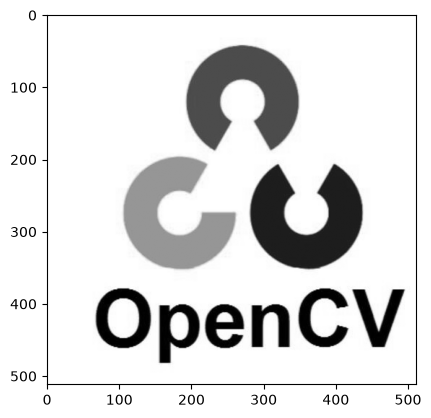

In [88]:
logo_gray = cv2.cvtColor(logo, cv2.COLOR_BGR2GRAY)
plt.imshow(logo_gray, cmap='gray')
plt.show()

In [90]:
# 200보다 넘는 값을 255로 변환
ret, mask = cv2.threshold(
    src=logo_gray,
    thresh=200,  # 200보다 넘는 값(임계값)
    maxval=255,  # 255
    type=cv2.THRESH_BINARY_INV,
)
mask

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(512, 512), dtype=uint8)

In [92]:
np.unique(mask)

array([  0, 255], dtype=uint8)

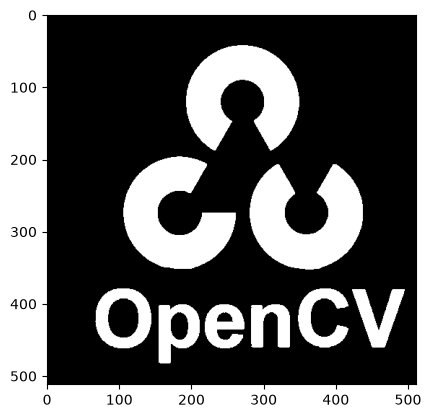

In [93]:
plt.imshow(mask, cmap='gray')
plt.show()

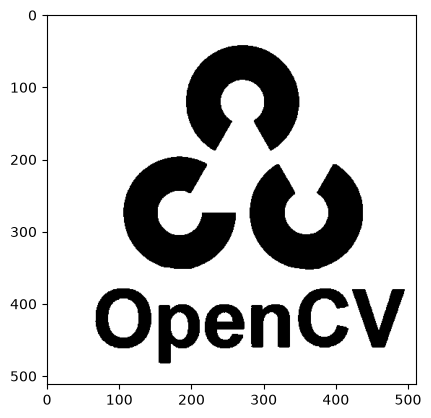

In [94]:
mask_inv = cv2.bitwise_not(mask)

plt.imshow(mask_inv, cmap='gray')
plt.show()

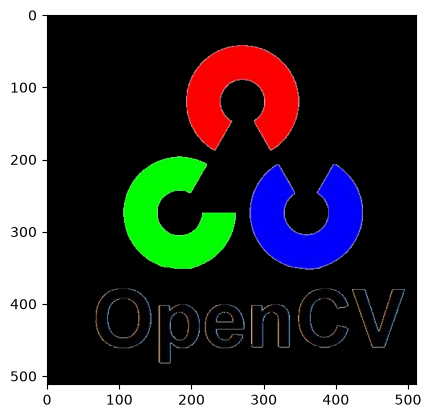

In [98]:
img1_fg = cv2.bitwise_and(logo, logo, mask=mask)
plt_imshow(img_fg)

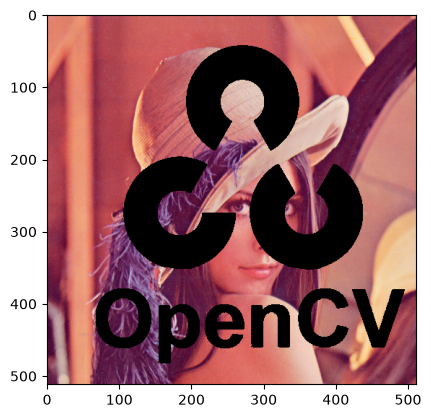

In [96]:
img2_bg = cv2.bitwise_and(lenna, lenna, mask=mask_inv)
plt_imshow(img2_bg)

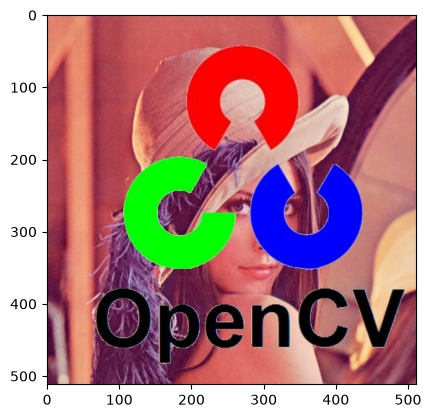

In [99]:
# 위 두 이미지를 합쳐보자
dst = cv2.add(img1_fg, img2_bg)
plt_imshow(dst)

## Image Blending
- `cv2.addWeighted()` 사용하여 두 이미지를 blending 할 수 있음

- blending 하려는 두 이미지의 사이즈가 같아야함!

- [Simple Formula]  
  # $\quad g(x) = (1 - \alpha) f_0(x) + \alpha f_1(x)$

  <br>

  - $\beta = 1 - \alpha$

  -  $\alpha, \beta $ 의 값을 통해 어떤 이미지를 더 강하게 드러내고, 어떤 이미지를 더 약하게 드러낼지 결정

  - $\gamma$ 추가 가능 (optional)



In [100]:
img1 = cv2.imread(os.path.join(base_path, 'fashion.jpg'))
img1 = cv2.cvtColor(img1, cv2.COLOR_BGR2RGB)
print(img1.shape) 
# (640, 640, 3)

img2 = cv2.imread(os.path.join(base_path, 'do-not-copy.jpg'))
img2 = cv2.cvtColor(img2, cv2.COLOR_BGR2RGB)
print(img2.shape)
# (1142, 1140, 3)


(640, 640, 3)
(1142, 1140, 3)


In [101]:
# bleanding 하려면 size를 맞춰야한다.
img1 = cv2.resize(img1, (640, 640))
img2 = cv2.resize(img2, (640, 640))

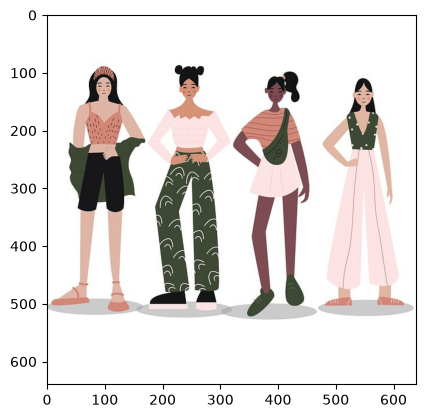

In [102]:
plt.imshow(img1)

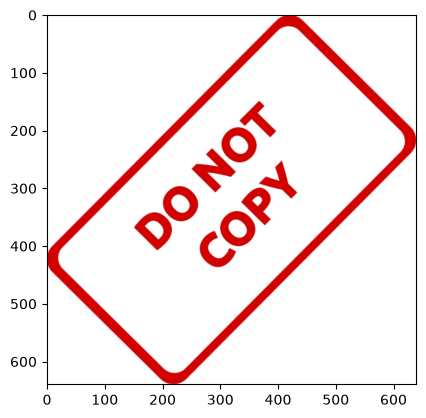

In [103]:
plt.imshow(img2)

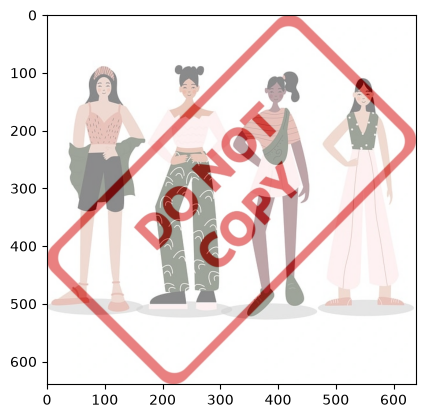

In [108]:
blended = cv2.addWeighted(
    src1=img1,
    alpha=0.5,  # scr1의 강도
    src2=img2,
    beta=0.5,  # scr2의 강도
    gamma=0,
)

plt.imshow(blended)
plt.show()

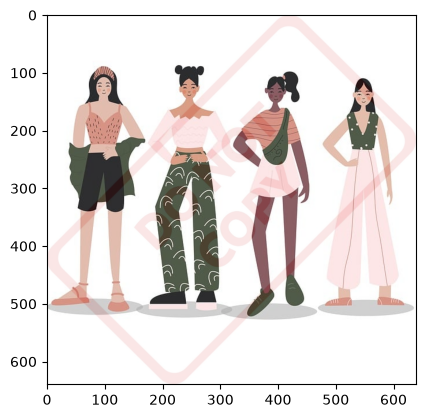

In [109]:
blended = cv2.addWeighted(
    src1=img1,
    alpha=0.9,  # scr1의 강도
    src2=img2,
    beta=0.1,  # scr2의 강도
    gamma=0,
)

plt.imshow(blended)
plt.show()